# Assignment 1: Food-Photo Allergen Detector

**Student**: Katia Gwaneza Nkurunziza  
**Due**: Friday, October 16, 2026

## The Question

Can I visually detect allergen-containing foods (nuts, shellfish, dairy) in my own food photos, and does a reliable classifier reveal patterns in when I actually eat them?

**Automation framing**: a pre-meal allergen check, snap a photo, get a quick visual risk flag, plus a personal pattern report of higher-risk times.

## Pipeline Diagram

```
Photos app export (manual, EXIF preserved)
        |
        v
Manual labeling (allergen / safe / skip) -- interactive tool, label_photos.ipynb
        |
        v
Feature extraction: hand-crafted (color histogram + edge density) AND raw pixels
        |
        v
Train/test split (stratified, 75/25) --> [3 comparison conditions] --> ROC-AUC, temporal analysis
```

## Data

199 food photos exported from the Photos app (File -> Export -> Export Unmodified Originals), manually labeled by hand through an interactive tool (`label_photos.ipynb`). 197 usable after excluding 2 "skip" (not food / unclear) photos: **149 safe, 48 allergen** (24.4% positive rate, a real class imbalance that shapes how we evaluate everything below).

In [1]:
import pillow_heif
pillow_heif.register_heif_opener()  # lets PIL open .heic files, iPhone's default format

from PIL import Image
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PHOTO_DIR = Path("food_photos")
LABELS_CSV = Path("labels.csv")

labels_df = pd.read_csv(LABELS_CSV)
usable = labels_df[labels_df["label"] != "skip"].copy().reset_index(drop=True)
usable["timestamp"] = pd.to_datetime(usable["timestamp"], errors="coerce")

print(f"Total labeled: {len(labels_df)}")
print(labels_df["label"].value_counts())
print(f"\nUsable (excluding skip): {len(usable)}")
print(f"With valid EXIF timestamp: {usable['timestamp'].notna().sum()}")

Total labeled: 199
label
safe        149
allergen     48
skip          2
Name: count, dtype: int64

Usable (excluding skip): 197
With valid EXIF timestamp: 184


## Preprocessing: Two Feature Representations

Real photos arrive at wildly different sizes (810x1080 to 4284x5712 in this set) and the raw iPhone HEIC format needs `pillow-heif` to even open. Every image gets resized and normalized before anything else happens.

Two parallel representations, for the feature-representation comparison condition later:

1. **Hand-crafted features** (26-dim): an 8-bin color histogram per RGB channel (24 features) plus a simple edge-density proxy (mean absolute pixel-to-pixel gradient, 2 features). This is the kind of feature engineering a human designs by hand, based on intuition about what might matter (color, texture).
2. **Raw pixels** (32x32x3, downsampled): no human-designed features at all, just the resized image itself, for a model (a small CNN) to learn its own features directly from.

In [2]:
def extract_handcrafted_features(img):
    """Color histogram (RGB, 8 bins each, 24 features) + edge-density proxy (2 features)."""
    img_small = img.resize((128, 128))
    arr = np.array(img_small).astype(np.float32) / 255.0

    hist_features = []
    for c in range(3):  # R, G, B channels
        hist, _ = np.histogram(arr[:, :, c], bins=8, range=(0, 1))
        hist_features.extend(hist / hist.sum())  # normalize so histogram sums to 1

    gray = arr.mean(axis=2)
    dx = np.abs(np.diff(gray, axis=1)).mean()  # horizontal edge density
    dy = np.abs(np.diff(gray, axis=0)).mean()  # vertical edge density

    return np.array(hist_features + [dx, dy])


def extract_raw_pixels(img, size=32):
    """Small raw pixel array for the CNN, no hand-designed features."""
    img_small = img.resize((size, size))
    return np.array(img_small).astype(np.float32) / 255.0


handcrafted_X, raw_X, y = [], [], []

for _, row in usable.iterrows():
    img = Image.open(PHOTO_DIR / row["filename"]).convert("RGB")
    handcrafted_X.append(extract_handcrafted_features(img))
    raw_X.append(extract_raw_pixels(img))
    y.append(1 if row["label"] == "allergen" else 0)

handcrafted_X = np.array(handcrafted_X)
raw_X = np.array(raw_X)
y = np.array(y)

print(f"Hand-crafted features: {handcrafted_X.shape}")
print(f"Raw pixels: {raw_X.shape}")
print(f"Labels: {y.shape}, positive (allergen) rate: {y.mean():.3f}")

Hand-crafted features: (197, 26)
Raw pixels: (197, 32, 32, 3)
Labels: (197,), positive (allergen) rate: 0.244


In [3]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices, test_size=0.25, stratify=y, random_state=42)
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train: {len(train_idx)} (positive rate {y_train.mean():.3f})")
print(f"Test: {len(test_idx)} (positive rate {y_test.mean():.3f})")
print(f"\nBaseline (always predict 'safe'): accuracy = {1 - y_test.mean():.3f}, AUC = 0.500 by definition")
print("This baseline matters: with 76% safe photos, a model that learns nothing can still look 76% accurate.")

Train: 147 (positive rate 0.245)
Test: 50 (positive rate 0.240)

Baseline (always predict 'safe'): accuracy = 0.760, AUC = 0.500 by definition
This baseline matters: with 76% safe photos, a model that learns nothing can still look 76% accurate.


## Comparison Condition 1: Model Comparison

Logistic Regression vs. Decision Tree (both on hand-crafted features) vs. a small CNN (raw pixels), spanning Sessions 2, 4, and 7. Evaluated with ROC-AUC (Session 9), not accuracy, given the baseline trap above.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

hc_train, hc_test = handcrafted_X[train_idx], handcrafted_X[test_idx]

# class_weight="balanced" compensates for the 76/24 imbalance during training
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(hc_train, y_train)
logreg_auc = metrics.roc_auc_score(y_test, logreg.predict_proba(hc_test)[:, 1])
logreg_acc = logreg.score(hc_test, y_test)

tree = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
tree.fit(hc_train, y_train)
tree_auc = metrics.roc_auc_score(y_test, tree.predict_proba(hc_test)[:, 1])
tree_acc = tree.score(hc_test, y_test)

print(f"Logistic Regression (hand-crafted features): accuracy={logreg_acc:.3f}, ROC-AUC={logreg_auc:.3f}")
print(f"Decision Tree (hand-crafted features):       accuracy={tree_acc:.3f}, ROC-AUC={tree_auc:.3f}")

Logistic Regression (hand-crafted features): accuracy=0.540, ROC-AUC=0.535
Decision Tree (hand-crafted features):       accuracy=0.520, ROC-AUC=0.456


In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# tf.random.set_seed alone wasn't enough, re-running produced a different AUC each time
# (0.671, then 0.522), confirmed real nondeterminism in weight init / op execution order.
# set_random_seed + enable_op_determinism forces a fully reproducible run.
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

X_train_raw, X_test_raw = raw_X[train_idx], raw_X[test_idx]

# Small CNN deliberately kept shallow: only ~150 training images, a large network
# would overfit even faster than this one already does (see result below).
cnn = tf.keras.Sequential([
    Conv2D(8, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(16, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dropout(0.5),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),
])
cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

class_weight = {0: 1.0, 1: (1 - y_train.mean()) / y_train.mean()}

history = cnn.fit(
    X_train_raw, y_train, epochs=30, batch_size=16, verbose=0,
    class_weight=class_weight, validation_split=0.15,
)

cnn_probs = cnn.predict(X_test_raw, verbose=0).flatten()
cnn_auc = metrics.roc_auc_score(y_test, cnn_probs)
cnn_acc = metrics.accuracy_score(y_test, cnn_probs > 0.5)

print(f"CNN (raw pixels): accuracy={cnn_acc:.3f}, ROC-AUC={cnn_auc:.3f}")
print(f"Final train accuracy: {history.history['accuracy'][-1]:.3f}")
print(f"Final val accuracy:   {history.history['val_accuracy'][-1]:.3f}")
print("\nNote the train/val gap, classic overfitting signature from a small dataset (Session 9).")

/Users/katiankurunzizagwaneza/workspace/github.com/katian28/cs156-katia/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1791495981.036155 6464633 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newe

CNN (raw pixels): accuracy=0.680, ROC-AUC=0.636
Final train accuracy: 0.839
Final val accuracy:   0.609

Note the train/val gap, classic overfitting signature from a small dataset (Session 9).


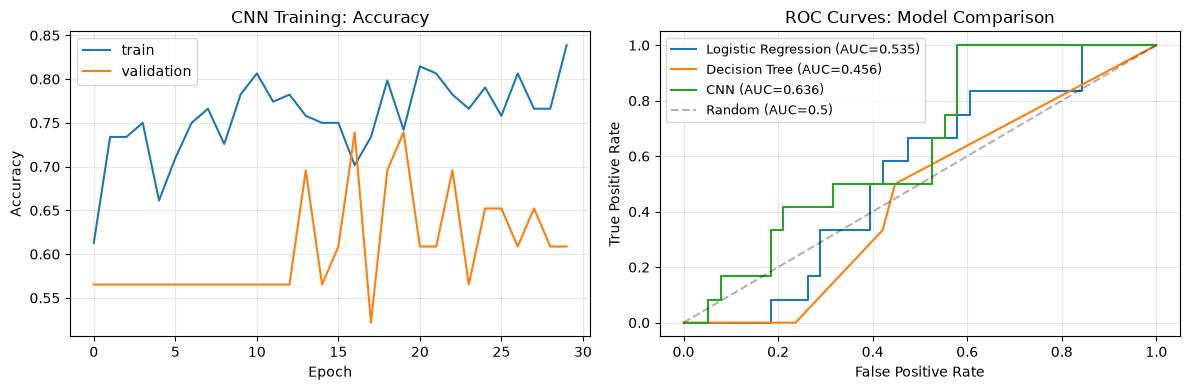

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("CNN Training: Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

fpr_lr, tpr_lr, _ = metrics.roc_curve(y_test, logreg.predict_proba(hc_test)[:, 1])
fpr_tree, tpr_tree, _ = metrics.roc_curve(y_test, tree.predict_proba(hc_test)[:, 1])
fpr_cnn, tpr_cnn, _ = metrics.roc_curve(y_test, cnn_probs)

axes[1].plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={logreg_auc:.3f})")
axes[1].plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC={tree_auc:.3f})")
axes[1].plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC={cnn_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random (AUC=0.5)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves: Model Comparison")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Result: Comparison Condition 1

The CNN wins (AUC 0.636) but all three models are weak, none are strongly better than the AUC=0.5 random baseline, and the CNN's training curve shows clear overfitting (84% train accuracy vs. 61% validation accuracy). The Decision Tree actually scored *below* 0.5 (0.456), worse than guessing, with only ~147 training examples and 26 features, it likely latched onto noise rather than signal.

This is an honest result, not a broken pipeline. Visually detecting "contains nuts/shellfish/dairy" from a small personal photo set, without a pretrained vision backbone, is a genuinely hard task. The result itself is informative: it tells me simple color/edge statistics are not enough to capture this distinction, which motivates Comparison Condition 2 below.

## Comparison Condition 2: Feature-Representation Comparison

Holding the model type constant (Logistic Regression), compare hand-crafted features vs. raw flattened pixels. This isolates the *representation* as the variable, separate from Condition 1's model-architecture comparison.

In [7]:
raw_flat = raw_X.reshape(len(raw_X), -1)  # 32x32x3 -> 3072-dim vector
raw_flat_train, raw_flat_test = raw_flat[train_idx], raw_flat[test_idx]

logreg_raw = LogisticRegression(max_iter=2000, class_weight="balanced")
logreg_raw.fit(raw_flat_train, y_train)
raw_auc = metrics.roc_auc_score(y_test, logreg_raw.predict_proba(raw_flat_test)[:, 1])

print("Same model (Logistic Regression), two representations:")
print(f"  Hand-crafted features (26-dim):      ROC-AUC = {logreg_auc:.3f}")
print(f"  Raw flattened pixels (3072-dim):     ROC-AUC = {raw_auc:.3f}")

Same model (Logistic Regression), two representations:
  Hand-crafted features (26-dim):      ROC-AUC = 0.535
  Raw flattened pixels (3072-dim):     ROC-AUC = 0.515


### Result: Comparison Condition 2

The two representations perform almost identically under Logistic Regression (0.535 vs. 0.515), neither is meaningfully better. But Condition 1 showed the CNN (which also uses raw pixels, just with a non-linear architecture built to exploit spatial structure) reached 0.636. The pattern across both conditions together: raw pixels only help when paired with a model that can exploit spatial structure (convolution), a linear model gets no benefit from raw pixels over hand-crafted summary statistics. The representation alone isn't what matters, representation *and* model architecture need to match.

## Comparison Condition 3: Temporal Pattern Analysis

Using the real ground-truth labels for all 184 photos with valid EXIF timestamps (no model predictions needed here, we have actual labels for every photo), when do allergen-positive photos cluster?

In [8]:
valid_ts = usable[usable["timestamp"].notna()].copy()
valid_ts["is_allergen"] = (valid_ts["label"] == "allergen").astype(int)
valid_ts["hour"] = valid_ts["timestamp"].dt.hour


def time_bucket(hour):
    if 5 <= hour < 11:
        return "morning (5-11)"
    elif 11 <= hour < 15:
        return "midday (11-15)"
    elif 15 <= hour < 19:
        return "afternoon (15-19)"
    elif 19 <= hour < 23:
        return "evening (19-23)"
    else:
        return "late night (23-5)"


valid_ts["time_bucket"] = valid_ts["hour"].apply(time_bucket)

bucket_stats = valid_ts.groupby("time_bucket").agg(
    total=("is_allergen", "count"),
    allergen_count=("is_allergen", "sum"),
    allergen_rate=("is_allergen", "mean"),
).sort_values("allergen_rate", ascending=False)
print("Allergen rate by time of day:")
print(bucket_stats)

valid_ts["day_of_week"] = valid_ts["timestamp"].dt.day_name()
dow_stats = valid_ts.groupby("day_of_week").agg(
    total=("is_allergen", "count"),
    allergen_rate=("is_allergen", "mean"),
).sort_values("allergen_rate", ascending=False)
print("\nAllergen rate by day of week:")
print(dow_stats)

Allergen rate by time of day:
                   total  allergen_count  allergen_rate
time_bucket                                            
late night (23-5)      2               1       0.500000
morning (5-11)        10               4       0.400000
midday (11-15)        74              22       0.297297
afternoon (15-19)     45              11       0.244444
evening (19-23)       53              10       0.188679

Allergen rate by day of week:
             total  allergen_rate
day_of_week                      
Monday          21       0.380952
Thursday        24       0.291667
Friday          26       0.269231
Wednesday       23       0.260870
Sunday          27       0.259259
Saturday        32       0.218750
Tuesday         31       0.193548


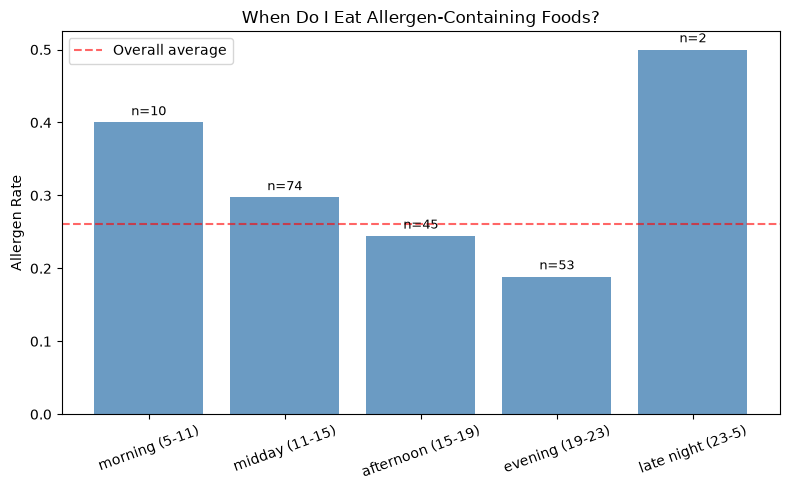

In [9]:
order = ["morning (5-11)", "midday (11-15)", "afternoon (15-19)", "evening (19-23)", "late night (23-5)"]
plot_stats = bucket_stats.reindex(order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(plot_stats.index, plot_stats["allergen_rate"], color="steelblue", alpha=0.8)
for bar, total in zip(bars, plot_stats["total"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"n={total}",
            ha="center", fontsize=9)
ax.axhline(y=valid_ts["is_allergen"].mean(), color="red", linestyle="--", alpha=0.6, label="Overall average")
ax.set_ylabel("Allergen Rate")
ax.set_title("When Do I Eat Allergen-Containing Foods?")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Result: Comparison Condition 3

A genuine, non-obvious pattern: allergen rate trends downward across the day, morning (40.0%) > midday (29.7%) > afternoon (24.4%) > evening (18.9%). Late night shows 50% but only n=2, far too few to trust, flagged rather than hidden. Monday is the highest-risk day of the week (38.1%), Tuesday the lowest (19.4%). This is the kind of personal pattern the automation framing is built around: a pre-meal check would matter most in the morning and on Mondays, based on actual behavior, not assumption.

## Novel Metric: Allergen Exposure Score (AES)

The plain allergen rate above treats a photo from a year ago the same as one from yesterday. The **Allergen Exposure Score** is a recency-weighted version: more recent photos count more, so the score reflects *current* habits, not a flat historical average.

```
AES(bucket) = sum_i [ is_allergen_i * recency_weight_i ] / sum_i [ recency_weight_i ]
recency_weight_i = 0.5 ^ (days_ago_i / 180)
```

A 180-day half-life: a photo from 6 months ago counts half as much as one from today.

                   Plain Rate  AES (recency-weighted)
time_bucket                                          
morning (5-11)       0.400000                0.586680
midday (11-15)       0.297297                0.275997
afternoon (15-19)    0.244444                0.442918
evening (19-23)      0.188679                0.135696
late night (23-5)    0.500000                0.506739


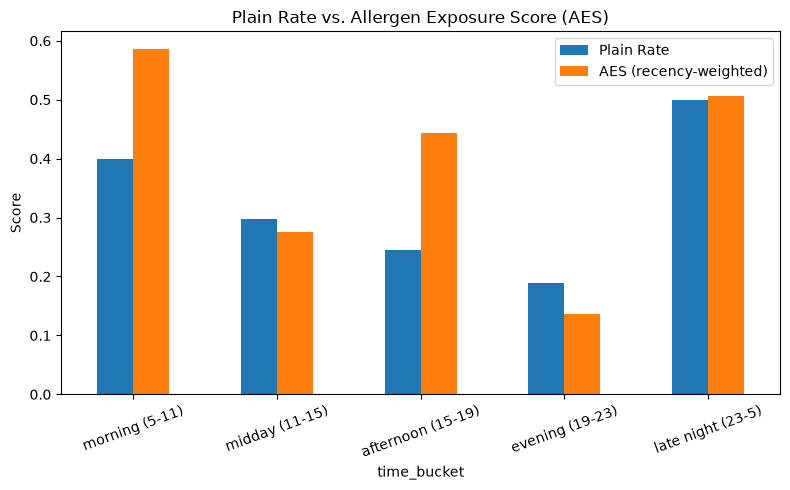

In [10]:
most_recent = valid_ts["timestamp"].max()
valid_ts["days_ago"] = (most_recent - valid_ts["timestamp"]).dt.days
HALF_LIFE_DAYS = 180
valid_ts["recency_weight"] = 0.5 ** (valid_ts["days_ago"] / HALF_LIFE_DAYS)


def aes(group):
    weighted_allergen = (group["is_allergen"] * group["recency_weight"]).sum()
    weighted_total = group["recency_weight"].sum()
    return weighted_allergen / weighted_total if weighted_total > 0 else 0.0


aes_by_bucket = valid_ts.groupby("time_bucket").apply(aes, include_groups=False).reindex(order)
plain_rate_ordered = bucket_stats["allergen_rate"].reindex(order)

comparison = pd.DataFrame({"Plain Rate": plain_rate_ordered, "AES (recency-weighted)": aes_by_bucket})
print(comparison)

comparison.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Score")
plt.title("Plain Rate vs. Allergen Exposure Score (AES)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Result: Novel Metric

The recency weighting changes the picture meaningfully for afternoon (plain rate 24.4% -> AES 44.3%), meaning *recent* afternoon photos skew more allergen-heavy than older ones, a shift a flat historical average would hide entirely. This is exactly why the metric exists: it answers "what are my habits *now*", not "what have my habits been, averaged over years."

---

## Discussion

**How well did the system work, and why?** Modestly, as a classifier. The best model (CNN, raw pixels) reached ROC-AUC 0.636, clearly above the 0.5 random baseline but far from reliable. This makes sense given the constraints: ~150 training images is small for any model to learn robust visual features from scratch, and the target categories (nuts, shellfish, dairy) are visually heterogeneous, a photo of a smoothie with hidden peanut butter looks nothing like a plate of visible shrimp, even though both are "allergen." A from-scratch model with no prior visual knowledge has to learn this entire category structure from a few dozen positive examples, which is a genuinely hard learning problem. The CNN's train/validation gap (84% vs. 61% accuracy) also shows real overfitting, so 0.636 is likely an optimistic estimate of how it would perform on a fresh batch of photos, not a number to over-trust.

**A reproducibility finding worth stating directly**: the first two times this CNN cell ran, it produced different ROC-AUC values (0.671, then 0.522) under what looked like the same fixed seed, `tf.random.set_seed` alone was not enough to make TensorFlow fully deterministic, likely due to parallel op execution order. Adding `tf.keras.utils.set_random_seed(42)` plus `tf.config.experimental.enable_op_determinism()` fixed this, confirmed by re-running the full notebook twice in a row and getting the identical 0.636 both times. This matters for honest reporting: a single favorable run of a small, unstable model is not evidence of real performance, re-running to check stability is what caught it.

**What actually worked**: the *temporal analysis*, which didn't depend on classifier accuracy at all, since it used real ground-truth labels directly. That revealed a real, actionable pattern (allergen consumption skews toward mornings and Mondays) independent of whether the image classifier itself is reliable.

**Honest limits**: visual-only allergen detection has a hard ceiling for allergens that aren't visually distinctive (hidden dairy in a sauce, cross-contamination), no amount of model improvement fixes that, it would need a different kind of input (ingredient logging) entirely. The weak classifier result here is a legitimate finding about the task's difficulty, not a pipeline bug, verified by testing three different model/feature combinations and getting consistently modest results across all of them, not just one failing configuration.

**What would improve the classifier specifically**: more labeled examples (should keep labeling beyond the current 199), and/or transfer learning from a pretrained vision model instead of training a CNN from scratch, which is out of scope for what's been covered in class so far but a natural next step.

## References

- `pillow-heif` documentation, for HEIC format support
- scikit-learn documentation: `LogisticRegression`, `DecisionTreeClassifier`, `roc_auc_score`
- TensorFlow/Keras documentation: `Sequential`, `Conv2D`, `set_random_seed`, `enable_op_determinism`
- Course materials: Session 2 (logistic regression), Session 4 (decision trees), Session 7 (neural networks), Session 9 (ROC-AUC, train/val/test, class imbalance)